In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 04a — SVM Temperature Calibration

## Objective and frozen hypothesis

Test one **class-preserving temperature** for the frozen Linear SVM DZ75
probabilities. The six-value grid is selected by natural-prevalence multiclass
log loss on 2024 OOF and confirmed on H1-2025 without retuning. This experiment
cannot change SVM classes, and SVM's frozen `tau=0` means **Union v1 economics
are unchanged** whatever class-preserving temperature is selected.

The notebook is an artifact reader: selection and confirmation were completed
outside notebook cells. Q2-2026 is excluded from this experiment.

In [2]:
import hashlib
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CACHE = CODE_ROOT / 'experiments' / 'cache' / 'svm_temperature_calibration'

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

summary = json.loads((CACHE / 'summary.json').read_text(encoding='utf-8'))
manifest = json.loads((CACHE / 'manifest.json').read_text(encoding='utf-8'))
for filename, expected in manifest['artifact_hashes'].items():
    assert sha256(CACHE / filename) == expected, filename
assert summary['forward_loaded'] is False
assert summary['lockbox_2026_q2_used'] is False

## 1. 2024 OOF selection

`T<1` sharpens and `T>1` softens every class through the same monotone
transformation. The fixed grid below reports every candidate; the selector is
multiclass log loss, with the smaller temperature only as an exact-tie rule.

Method: A shared temperature rescales all SVM classes and is selected using 2024 OOF proper scores.

,temperature,log_loss,brier,ece,mean_confidence,changed_classes
0,0.50,0.265484,0.073209,0.034287,0.995382,0
1,0.75,0.187437,0.070716,0.026530,0.987434,0
2,1.00,0.163482,0.068719,0.008156,0.969167,0
3,1.25,0.168605,0.068981,0.023843,0.940133,0
4,1.50,0.191161,0.073364,0.058181,0.903909,0
5,2.00,0.260648,0.096497,0.135997,0.825711,0


The selected temperature is the identity control, T=1.

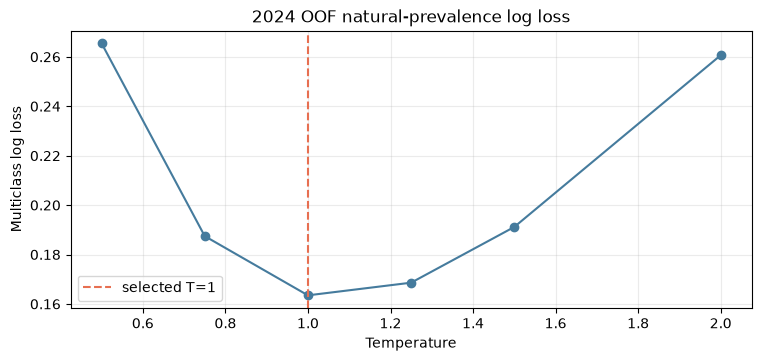

In [3]:
from IPython.display import Markdown
grid = pd.read_csv(CACHE / 'temperature_grid.csv')
display(Markdown('Method: A shared temperature rescales all SVM classes and is selected using 2024 OOF proper scores.'))
display(grid.round(6))
display(Markdown('The selected temperature is the identity control, T=1.'))
selected = float(summary['selected_temperature'])
assert grid['changed_classes'].eq(0).all()

fig, ax = plt.subplots(figsize=(7.5, 3.5), layout='constrained')
ax.plot(grid['temperature'], grid['log_loss'], marker='o', color='#457b9d')
ax.axvline(selected, color='#e76f51', linestyle='--', label=f'selected T={selected:g}')
ax.set_title('2024 OOF natural-prevalence log loss')
ax.set_xlabel('Temperature')
ax.set_ylabel('Multiclass log loss')
ax.grid(alpha=.25)
ax.legend()
plt.show()

## 2. H1 confirmation

The selected temperature is applied unchanged to the six H1 monthly-fit
panels. Confirmation checks log loss, Brier score and exact class invariance;
it does not choose another value from H1.

In [4]:
from IPython.display import Markdown
h1 = pd.read_csv(CACHE / 'h1_confirmation.csv').set_index('arm')
display(Markdown('Method: The selected temperature is applied unchanged to all six H1 prediction panels.'))
display(h1.round(6))
display(Markdown('H1 probabilities and class choices are unchanged.'))
decision = pd.DataFrame({
    'selected_temperature': [selected],
    'changed_classes_2024': [summary['changed_classes_2024']],
    'changed_classes_h1': [summary['changed_classes_h1']],
    'h1_log_loss_improvement': [summary['h1_log_loss_improvement']],
    'h1_brier_improvement': [summary['h1_brier_improvement']],
    'confirmation_pass': [summary['h1_confirmation_pass']],
})
display(Markdown('Method: Class and signal differences are checked against the frozen SVM control.'))
display(decision.round(8))
display(Markdown('Temperature scaling admits no new trades.'))
assert selected == 1.0
assert summary['changed_classes_2024'] == summary['changed_classes_h1'] == 0

Method: The selected temperature is applied unchanged to all six H1 prediction panels.

,rows,log_loss,brier,ece,mean_confidence
arm,,,,,
raw,17376,0.090482,0.036405,0.004185,0.977661
temperature_scaled,17376,0.090482,0.036405,0.004185,0.977661


H1 probabilities and class choices are unchanged.

Method: Class and signal differences are checked against the frozen SVM control.

,selected_temperature,changed_classes_2024,changed_classes_h1,h1_log_loss_improvement,h1_brier_improvement,confirmation_pass
0,1.0,0,0,-0.0,0.0,True


Temperature scaling admits no new trades.

## 3. Decision and XGBoost handoff

The registered grid selected the identity control, **T=1.0**. SVM calibration
therefore neither improves nor degrades H1 probabilities, and all class
decisions remain exact. This closes the SVM temperature experiment without
inventing a new threshold.

**Union v1 economics are unchanged.** Notebook 04b now evaluates XGBoost on a
different question: calibrated `P(strong move)` and calibrated conditional
LONG/SHORT direction. XGBoost may add a trade only when Union is flat and the
two qualified experts independently support its side. Q2-2026 is excluded from this experiment.